# AthenaK Dust–Gas Drag Module: Phase-1 Validation

This notebook reproduces the validation of the Lagrangian dust module implemented in `athenak/src/dust/`:
the **Yang & Johansen (2016)** particle-mesh method (TSC scatter/gather + exact momentum-conserving
back-reaction, PMBR) coupled to the **Krapp et al. (2024)** IMEX(4,3,2) integrator (`imex2+`) with the
O(N) closed-form per-cell drag solve of **Benítez-Llambay, Krapp & Pessah (2019)**, generalized to
per-particle stopping times.

The algorithm spec is `literature/imex_dust_algorithm.pdf`. Five properties are guaranteed by construction
and each is verified by a test below:

| # | Property | Test |
|---|----------|------|
| 1 | Second-order accuracy in time and space | §2 damping (dt), §6 dusty wave (dx) |
| 2 | No time-step constraint from drag (any $t_s$, any $\epsilon$) | §4 stiff regime, $\Delta t/t_s$ up to 125 |
| 3 | Total gas+dust momentum conserved to machine precision | every test (last column of the error files) |
| 4 | L-stable: $\Delta t \gg t_s$ relaxes to the exact equilibrium | §4 stiff regime |
| 5 | Correct coupled dynamics (drag × pressure/flux terms unsplit) | §6 damped dusty sound wave |

Two additional checks: **§5** MPI domain decomposition (per-stage particle migration + the additive
deposit halo exchange must give rank-count-independent results), and **§7** regressions (ion-neutral
C-shock, cosmic-ray particles, plain hydro are unchanged).

Each test cell prints a PASS/FAIL verdict and the numerical reference used by the assertion. The serial
suite takes a few minutes; the MPI and cosmic-ray regression checks run only when their optional builds
are available.


## 1. Test setup

### Problem generators

The drag tests use the built-in `dust_damping` and `dusty_wave` problem generators in
`athenak/src/pgen/tests/dust_damping.cpp` and `athenak/src/pgen/tests/dusty_wave.cpp`.
AthenaK is compiled with `-DPROBLEM=built_in_pgens`; each input selects its generator at runtime
with `<problem>/pgen_name`. The final regression section additionally uses problem generators and
inputs shipped with AthenaK.

### CPU builds

From the directory containing both `athenak/` and `athenak_dust_tests/`:

```bash
cmake -S athenak -B athenak/build \
  -DCMAKE_BUILD_TYPE=Release \
  -DPROBLEM=built_in_pgens
cmake --build athenak/build -j
```

The notebook performs this serial build if the executable is missing. The optional MPI test (§5)
uses `athenak/build-mpi/src/athena`; configure that build with
`-DAthena_ENABLE_MPI=ON` and launch it with the `mpirun` associated with the MPI toolchain used
for the build.

### Inputs and execution

Tracked inputs used directly by the dust tests are:

```text
athenak_dust_tests/inputs/dust_damping.athinput
athenak_dust_tests/inputs/dusty_wave.athinput
```

The regression checks continue to use the standard files under `athenak/inputs/`. Start Jupyter
from the directory containing both repositories, open this notebook, and select **Run All**. Runtime
outputs are written under `athenak/build/run-notebook/`; a temporary three-species dusty-wave input
is generated there without modifying the tracked templates.

In [1]:
import subprocess, shutil, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT/'athenak').is_dir() and (ROOT/'athenak_cc'/'athenak').is_dir():
    ROOT = ROOT/'athenak_cc'
assert (ROOT/'athenak').is_dir() and (ROOT/'athenak_dust_tests').is_dir(), \
    'start Jupyter from the directory containing athenak/ and athenak_dust_tests/, or its parent'

ATHENA     = ROOT/'athenak/build/src/athena'
ATHENA_MPI = ROOT/'athenak/build-mpi/src/athena'
CODE_INPUTS = ROOT/'athenak/inputs'
TEST_INPUTS = ROOT/'athenak_dust_tests/inputs'
MPIRUN      = os.environ.get('MPIRUN') or shutil.which('mpirun')
WORK       = ROOT/'athenak/build/run-notebook'
WORK.mkdir(parents=True, exist_ok=True)

if not ATHENA.exists():
    print('building AthenaK (serial)... this takes a few minutes')
    subprocess.run(['cmake','-S',str(ROOT/'athenak'),'-B',str(ROOT/'athenak/build'),
                    '-DCMAKE_BUILD_TYPE=Release','-DPROBLEM=built_in_pgens'], check=True)
    subprocess.run(['cmake','--build',str(ROOT/'athenak/build'),'-j8'], check=True)
print('serial binary :', ATHENA.exists(), '-', ATHENA)
print('MPI binary    :', ATHENA_MPI.exists(), '-', ATHENA_MPI, '(only needed for §5)')

def run_athena(inputfile, *overrides, exe=None, nranks=None):
    """Run athena in WORK with parameter overrides; raise on failure."""
    exe = exe or ATHENA
    if nranks and not MPIRUN:
        raise RuntimeError('mpirun not found; put it on PATH or set the MPIRUN environment variable')
    cmd = ([MPIRUN,'-np',str(nranks)] if nranks else []) + [str(exe), '-i', str(inputfile)] + list(overrides)
    res = subprocess.run(cmd, cwd=WORK, capture_output=True, text=True)
    if res.returncode != 0:
        print(res.stdout[-3000:]); print(res.stderr[-3000:])
        raise RuntimeError('athena failed: ' + ' '.join(cmd))
    return res

def read_errs(basename):
    return np.atleast_2d(np.loadtxt(WORK/f'{basename}-errs.dat'))

def clear_errs(basename):
    (WORK/f'{basename}-errs.dat').unlink(missing_ok=True)

def verdict(ok, msg):
    print(('PASS  ' if ok else '*** FAIL ***  ') + msg)
    return ok

## 2. N-species damping: second-order convergence in $\Delta t$

**Physics** (Krapp et al. 2024 §3.1; BKP19 §3.1). A uniform gas at rest is coupled to $N=3$ dust species
with stopping times $t_s = (0.01,\,0.1,\,1.0)$, dust-to-gas ratio $\epsilon_s = 1/3$ each, and initial
velocities $v_s(0) = v_0\,(s{+}1)/N$ with $v_0=0.01$. The spatially uniform system obeys the linear ODEs
$$\dot u = \sum_s \epsilon_s\,(v_s-u)/t_{s},\qquad \dot v_s = -(v_s-u)/t_{s}.$$

**Discretization trick that makes the comparison exact:** the pgen (`pgen/tests/dust_damping.cpp`,
`lattice=true`) places one particle of *every* species at *every* cell center (`ppc=3`). Every cell then
holds an identical dust mixture, all deposited fields are exactly uniform, fluxes vanish identically, and
the discrete update per cell equals the imex2+ DIRK map of the ODE system — so the measured error is purely
the time-integration error, which must converge as $\Delta t^2$. (§3 verifies this against an independent
implementation of the DIRK map.)

Note the first run has $\Delta t = 0.0125 > t_{s,1} = 0.01$: the fastest species is *in the stiff regime*
and the scheme must (and does) remain accurate.

The error file columns are: `Nx1 Nx2 Nx3 Ncycle err_u err_v1 err_v2 err_v3 err_momentum`, where the errors
are absolute differences of the mean velocities against a fine-step RK4 reference of the ODEs, and
`err_momentum` is the change in total gas+dust x-momentum over the whole run.

In [2]:
inp = TEST_INPUTS/'dust_damping.athinput'
clear_errs('dust_damping')
cfls = [0.4, 0.2, 0.1, 0.05]
for cfl in cfls:
    run_athena(inp, 'particles/ppc=3', f'time/cfl_number={cfl}')
E = read_errs('dust_damping')

print('   dt        err_u       err_v1      err_v2      err_v3      |dP_total|')
dts = 1.0/E[:,3]   # tlim=1, so dt ~ 1/ncycle
for r, dt in zip(E, dts):
    print(f'{dt:9.2e}  {r[4]:.4e}  {r[5]:.4e}  {r[6]:.4e}  {r[7]:.4e}  {r[8]:.2e}')

orders = np.log(E[:-1,4]/E[1:,4])/np.log(dts[:-1]/dts[1:])
print('\nconvergence order of err_u between consecutive runs:', np.round(orders,2))
print('\nreference (2026-07-14): err_u = 1.3529e-07, 3.4627e-08, 8.7724e-09, 2.2075e-09; |dP| ~ 1e-16')
ok  = verdict(np.all(np.abs(orders-2.0) < 0.35), 'err_u converges at 2nd order in dt')
ok &= verdict(np.all(E[:,8] < 1e-13), 'total momentum conserved to round-off in all runs')

   dt        err_u       err_v1      err_v2      err_v3      |dP_total|
 1.23e-02  1.3529e-07  1.3711e-07  1.4641e-07  6.8939e-07  1.64e-16
 6.21e-03  3.4627e-08  3.5096e-08  3.7325e-08  1.7630e-07  7.46e-17
 3.12e-03  8.7724e-09  8.8920e-09  9.4213e-09  4.4631e-08  1.99e-16
 1.56e-03  2.2075e-09  2.2377e-09  2.3649e-09  1.1225e-08  1.67e-16

convergence order of err_u between consecutive runs: [1.98 1.99 1.99]

reference (2026-07-14): err_u = 1.3529e-07, 3.4627e-08, 8.7724e-09, 2.2075e-09; |dP| ~ 1e-16
PASS  err_u converges at 2nd order in dt
PASS  total momentum conserved to round-off in all runs


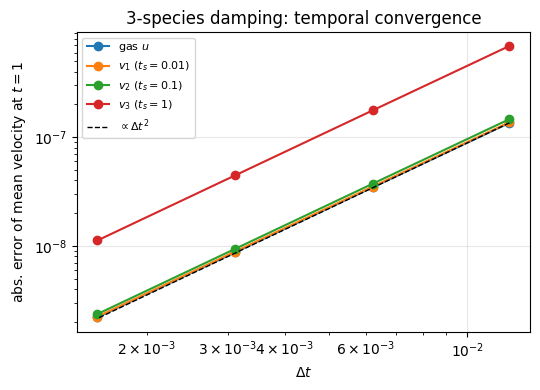

In [3]:
fig, ax = plt.subplots(figsize=(5.5,4))
for col, lab in [(4,'gas $u$'),(5,'$v_1$ ($t_s{=}0.01$)'),(6,'$v_2$ ($t_s{=}0.1$)'),(7,'$v_3$ ($t_s{=}1$)')]:
    ax.loglog(dts, E[:,col], 'o-', label=lab)
ax.loglog(dts, E[0,4]*(dts/dts[0])**2, 'k--', lw=1, label=r'$\propto\Delta t^2$')
ax.set_xlabel(r'$\Delta t$'); ax.set_ylabel('abs. error of mean velocity at $t=1$')
ax.set_title('3-species damping: temporal convergence'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Independent cross-check: the exact DIRK map

To confirm the code implements *exactly* the intended integrator (and that §2's errors are pure,
irreducible truncation error of the scheme rather than an implementation artifact), we re-implement the
per-cycle imex2+ map here from the tableau alone — two backward-Euler drag solves composed with the
low-storage explicit combination and the single $\tilde a_{22}$ history term — and iterate it at the same
$\Delta t$ values. **The code's errors above should match these to ~1% (differences come only from the
final-step clamp to `tlim`).**

In [4]:
g   = 1.0 + 1.0/np.sqrt(2.0)                 # imex2+ gamma (driver.cpp)
g0  = (2*g-1)/(2*g*g); g1 = 1-g0             # gam0[1], gam1[1]
a22 = (1-2*g*g)/(2*g)                        # only nonzero a_twid entry
eps = np.array([1/3,1/3,1/3]); ts = np.array([0.01,0.1,1.0])
v00 = 0.01*np.array([1,2,3])/3.0

def dirk_run(dt, T):
    n = int(round(T/dt)); u, v = 0.0, v00.copy()
    for _ in range(n):
        un, vn = u, v.copy()
        a = g*dt; c = a/(ts+a)                                  # c_j = a/(t_s+a)
        ust = (u + np.sum(eps*c*v))/(1+np.sum(eps*c))           # stage-1 cell solve
        dv = c*(ust-v); v1 = v+dv; Rs = dv/a; Ru = (ust-u)/a    # kick + recorded rates
        ub = g0*ust + g1*un + a22*dt*Ru                         # stage-2 explicit + history
        vb = g0*v1  + g1*vn + a22*dt*Rs
        ust2 = (ub + np.sum(eps*c*vb))/(1+np.sum(eps*c))        # stage-2 cell solve
        u, v = ust2, vb + c*(ust2-vb)
    return u, v

def rk4_ref(T, n=400000):
    h = T/n; y = np.concatenate([[0.0], v00])
    rhs = lambda w: np.concatenate([[np.sum(eps*(w[1:]-w[0])/ts)], -(w[1:]-w[0])/ts])
    for _ in range(n):
        k1=rhs(y); k2=rhs(y+0.5*h*k1); k3=rhs(y+0.5*h*k2); k4=rhs(y+h*k3)
        y += (h/6)*(k1+2*k2+2*k3+k4)
    return y[0], y[1:]

uref, vref = rk4_ref(1.0)
print('   dt        DIRK-map err_u   code err_u    ratio')
ok_map = True
for dt_c, code_err in zip(dts, E[:,4]):
    u, v = dirk_run(1.0/round(1.0/dt_c), 1.0)
    map_err = abs(u-uref)
    print(f'{dt_c:9.2e}   {map_err:.4e}     {code_err:.4e}   {code_err/map_err:6.3f}')
    ok_map &= abs(code_err/map_err - 1.0) < 0.05
ok &= verdict(ok_map, 'code errors equal the exact imex2+ DIRK-map errors (within final-step clamp)')

   dt        DIRK-map err_u   code err_u    ratio
 1.23e-02   1.3300e-07     1.3529e-07    1.017
 6.21e-03   3.4442e-08     3.4627e-08    1.005
 3.12e-03   8.7692e-09     8.7724e-09    1.000
 1.56e-03   2.2060e-09     2.2075e-09    1.001
PASS  code errors equal the exact imex2+ DIRK-map errors (within final-step clamp)


## 4. Stiff regime and asymptotic exactness ($\Delta t \gg t_s$)

The payoff of the implicit scheme: with $t_s = (10^{-4},10^{-3},2\times10^{-3})$ and the hydro-CFL step
$\Delta t = 0.0125$ (so $\Delta t/t_{s,1} = 125$), an explicit integrator would need a ~1000× smaller
step or blow up. The L-stable solve instead lands the whole system on the exact common (center-of-mass)
velocity, which the exact momentum bookkeeping then preserves **to round-off**: every error should be
$\sim10^{-16}$, not merely small. The γ-switch variant (Krapp Eq. 18: $\gamma\to1/2$ when
$\Delta t > \max t_s$) must give the same result; and with the default $t_s$ (non-stiff) the switch must
leave results bit-identical to fixed γ.

In [5]:
clear_errs('dust_damping')
stiff = ['dust/taus_1=0.0001','dust/taus_2=0.001','dust/taus_3=0.002']
run_athena(inp, 'particles/ppc=3', *stiff)                            # gamma = 1+1/sqrt(2) fixed
run_athena(inp, 'particles/ppc=3', *stiff, 'dust/gamma_switch=true')  # gamma -> 1/2 branch
run_athena(inp, 'particles/ppc=3', 'dust/gamma_switch=true')          # non-stiff, switch inactive
S = read_errs('dust_damping')
print('stiff, fixed gamma      :', S[0,4:])
print('stiff, gamma-switch     :', S[1,4:])
print('non-stiff, switch on    :', S[2,4:], ' (compare 1.3529e-07 ... from section 2, row 1)')
ok &= verdict(np.all(S[0,4:8] < 1e-13), 'dt/ts = 125: equilibrium exact to round-off (L-stability)')
ok &= verdict(np.all(S[1,4:8] < 1e-13), 'same with gamma-switch enabled')
ok &= verdict(np.allclose(S[2,4:8], E[0,4:8], rtol=1e-12), 'switch inactive when dt < max(ts): bit-identical')

stiff, fixed gamma      : [1.049508e-16 1.071192e-16 1.266348e-16 6.158268e-17 1.092876e-16]
stiff, gamma-switch     : [1.049508e-16 1.071192e-16 1.266348e-16 6.158268e-17 1.092876e-16]
non-stiff, switch on    : [1.352906e-07 1.371073e-07 1.464113e-07 6.893905e-07 1.639314e-16]  (compare 1.3529e-07 ... from section 2, row 1)
PASS  dt/ts = 125: equilibrium exact to round-off (L-stability)
PASS  same with gamma-switch enabled
PASS  switch inactive when dt < max(ts): bit-identical


### Random particle positions (PMBR + halo exchange under real spatial structure)

With `lattice=false`, particles are placed at random positions, so TSC deposits genuinely straddle
MeshBlock boundaries and the additive halo exchange (`MeshBoundaryValuesDep`) plus the u* ghost fill are
exercised with non-trivial data (4 MeshBlocks). The mean velocities now deviate from the homogeneous ODE
at the ~$10^{-5}$ level — that is *physical* (density fluctuations couple to pressure), not an error —
but momentum conservation must remain exact, and the deposit scheme (`ngp`/`tsc`) and block layout must
not matter for it.

In [6]:
clear_errs('dust_damping')
run_athena(inp, 'particles/ppc=4', 'problem/lattice=false')                       # random, TSC, 4 blocks
run_athena(inp, 'particles/ppc=4', 'problem/lattice=false', 'dust/deposit=ngp')   # random, NGP
run_athena(inp, 'particles/ppc=3', 'meshblock/nx1=32', 'meshblock/nx2=32')        # lattice, single block
R = read_errs('dust_damping')
for lab, r in zip(['random TSC 4-block ','random NGP 4-block ','lattice single-block'], R):
    print(f'{lab}: err_u={r[4]:.3e}  |dP|={r[8]:.2e}')
ok &= verdict(np.all(R[:,8] < 1e-13), 'momentum exact for random positions, NGP/TSC, any block layout')
ok &= verdict(np.allclose(R[2,4:8], E[0,4:8], rtol=1e-12), 'single-block lattice identical to 4-block (halo exchange exact)')

random TSC 4-block : err_u=5.286e-06  |dP|=3.76e-16
random NGP 4-block : err_u=5.770e-06  |dP|=3.69e-16
lattice single-block: err_u=1.353e-07  |dP|=1.64e-16
PASS  momentum exact for random positions, NGP/TSC, any block layout
PASS  single-block lattice identical to 4-block (halo exchange exact)


## 5. MPI: rank-count independence (optional — needs `build-mpi` and `mpirun`)

Per-stage particle migration, the deposit add-exchange, the u* ghost fill, and the PMBR exchange all cross
rank boundaries here. With `v0=0.5` particles drift across MeshBlocks and wrap the periodic boundary many
times during the run (which also transports the RK position registers). **1-rank and 4-rank runs must agree
to near round-off** (tiny differences only from MPI reduction order in the diagnostics).
Reference: `err_u = 1.158578e-05` for both.

In [7]:
if ATHENA_MPI.exists() and MPIRUN:
    clear_errs('dust_damping')
    mig = ['particles/ppc=3', 'problem/v0=0.5', 'dust/taus_3=0.5']
    run_athena(inp, *mig, exe=ATHENA_MPI, nranks=1)
    run_athena(inp, *mig, exe=ATHENA_MPI, nranks=4)
    M = read_errs('dust_damping')
    print('1 rank :', M[0,4:]); print('4 ranks:', M[1,4:])
    ok &= verdict(np.allclose(M[0,4:8], M[1,4:8], rtol=1e-9), '1-rank and 4-rank results identical')
    ok &= verdict(np.all(M[:,8] < 1e-13), 'momentum exact across ranks')
else:
    print('SKIPPED - build the MPI binary first:')
    print('  cmake -S athenak -B athenak/build-mpi -D CMAKE_BUILD_TYPE=Release -D Athena_ENABLE_MPI=ON')
    print('  cmake --build athenak/build-mpi -j')
    print('If needed, set MPIRUN to the matching launcher before starting Jupyter.')

1 rank : [1.158578e-05 1.187422e-05 1.490167e-05 6.153323e-05 5.218048e-15]
4 ranks: [1.158578e-05 1.187422e-05 1.490167e-05 6.153323e-05 3.552714e-15]
PASS  1-rank and 4-rank results identical
PASS  momentum exact across ranks


## 6. Damped dusty sound wave: drag × pressure coupling, spatial convergence

**Physics** (Laibe & Price 2011; Krapp et al. 2024 §3.2). The gas is initialized with the exact complex
eigenmode of the linearized gas–dust system for a right-traveling wave, and dust particles are placed on a
displaced lattice imprinting the dust density wave. Perturbations evolve as $e^{i(kx-\omega t)}$ with
$\omega$ the damped root of
$$\omega^2\Big(1+\sum_s\frac{\epsilon_s}{1-i\omega t_{s}}\Big) = k^2 c_s^2 ,$$
which we re-derive and solve independently below (the code prints its own root in the error file — they
must agree to all digits). This test exercises the full coupling: deposits, cell solve, gather, PMBR,
*and* the hydro fluxes/pressure, with the drag applied unsplit inside the IMEX stages. L1 field errors
against the analytic damped wave must converge at second order in resolution.

A subtlety worth knowing when reproducing plots: for a *pure traveling* eigenmode the volume-integrated
kinetic energy decays smoothly as $e^{2\,\mathrm{Im}(\omega)t}$ **without oscillating**; an oscillating
KE history signals contamination by the counter-propagating mode (i.e., an initialization error —
this diagnostic caught a real/imaginary-part sign bug during development).

In [8]:
def dusty_wave_omega(k, cs, eps, ts, tol=1e-15):
    """Newton solve of the dispersion relation, from the tightly-coupled limit."""
    eps, ts = np.asarray(eps), np.asarray(ts)
    w = k*cs/np.sqrt(1.0+eps.sum()) + 0j
    for _ in range(100):
        den = 1.0 - 1j*w*ts
        f  = w*w*(1 + np.sum(eps/den)) - (k*cs)**2
        fp = 2*w*(1 + np.sum(eps/den)) + w*w*np.sum(eps*1j*ts/den**2)
        dw = f/fp; w -= dw
        if abs(dw) < tol*abs(w): break
    return w

w1 = dusty_wave_omega(2*np.pi, 1.0, [1.0], [0.1])
print(f'independent dispersion root (1 species, ts=0.1, eps=1): {w1:.6f}')
print( 'code value written in the error file below should be  : 4.529763 - 0.492158i')

independent dispersion root (1 species, ts=0.1, eps=1): 4.529763-0.492158j
code value written in the error file below should be  : 4.529763 - 0.492158i


 Nx1    L1_drho     L1_dvx     Re(omega)  Im(omega)
  16  6.2710e-08  4.5114e-08   4.529763  -0.492158
  32  1.8363e-08  1.3514e-08   4.529763  -0.492158
  64  6.8962e-09  5.1242e-09   4.529763  -0.492158
 128  1.8374e-09  1.3775e-09   4.529763  -0.492158

reference: L1_drho = 6.2710e-08, 1.8363e-08, 6.8962e-09, 1.8374e-09
note: for Nx1<=64 dt is limited by the fixed x2 grid, so the middle step mixes dx- and dt-error;
the first and last steps show the full 2nd order.

overall convergence order (16->128): 1.70
PASS  dusty wave converges at ~2nd order in resolution
PASS  code dispersion root matches independent Newton solve


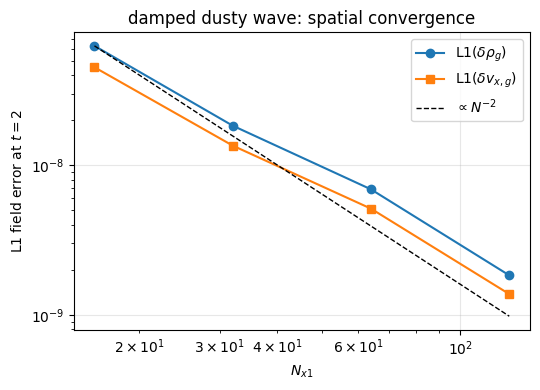

In [9]:
inpw = TEST_INPUTS/'dusty_wave.athinput'
clear_errs('dusty_wave')
nxs = [16, 32, 64, 128]
for nx in nxs:
    run_athena(inpw, f'mesh/nx1={nx}', f'meshblock/nx1={nx//2}')
W = read_errs('dusty_wave')
print(' Nx1    L1_drho     L1_dvx     Re(omega)  Im(omega)')
for r in W:
    print(f'{int(r[0]):4d}  {r[4]:.4e}  {r[5]:.4e}  {r[6]:9.6f}  {r[7]:9.6f}')
print('\nreference: L1_drho = 6.2710e-08, 1.8363e-08, 6.8962e-09, 1.8374e-09')
print('note: for Nx1<=64 dt is limited by the fixed x2 grid, so the middle step mixes dx- and dt-error;')
print('the first and last steps show the full 2nd order.')
oallw = np.log(W[0,4]/W[-1,4])/np.log(nxs[-1]/nxs[0])
print(f'\noverall convergence order (16->128): {oallw:.2f}')
ok &= verdict(oallw > 1.6, 'dusty wave converges at ~2nd order in resolution')
ok &= verdict(abs(W[0,6]-w1.real) < 1e-4 and abs(W[0,7]-w1.imag) < 1e-4,
              'code dispersion root matches independent Newton solve')

fig, ax = plt.subplots(figsize=(5.5,4))
ax.loglog(nxs, W[:,4], 'o-', label=r'L1($\delta\rho_g$)')
ax.loglog(nxs, W[:,5], 's-', label=r'L1($\delta v_{x,g}$)')
ax.loglog(nxs, W[0,4]*(nxs[0]/np.array(nxs))**2, 'k--', lw=1, label=r'$\propto N^{-2}$')
ax.set_xlabel('$N_{x1}$'); ax.set_ylabel('L1 field error at $t=2$')
ax.set_title('damped dusty wave: spatial convergence'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
# multi-species variant (3 species). taus_2/taus_3 are new parameters, which cannot be
# added from the command line, so patch a temporary copy of the input file.
txt = (TEST_INPUTS/'dusty_wave.athinput').read_text()
txt = txt.replace('nspecies      = 1', 'nspecies      = 3')
txt = txt.replace('ppc           = 1.0', 'ppc           = 3.0')
txt = txt.replace('taus_1        = 0.1       # stopping time of species 1',
                  'taus_1 = 0.01\ntaus_2 = 0.05\ntaus_3 = 0.1')
inpw3 = WORK/'dusty_wave_3sp.athinput'; inpw3.write_text(txt)

w3 = dusty_wave_omega(2*np.pi, 1.0, [1/3,1/3,1/3], [0.01,0.05,0.1])
clear_errs('dusty_wave')
for nx in [32, 64, 128]:
    run_athena(inpw3, f'mesh/nx1={nx}', f'meshblock/nx1={nx//2}')
W3 = read_errs('dusty_wave')
print(' Nx1    L1_drho     L1_dvx');
for r in W3: print(f'{int(r[0]):4d}  {r[4]:.4e}  {r[5]:.4e}')
print(f'\nindependent omega: {w3:.6f}   code: {W3[0,6]:.6f} {W3[0,7]:+.6f}i')
print('reference: 2.9596e-08, 9.8440e-09, 2.6867e-09;  omega = 4.493875 - 0.252246i')
o3 = np.log(W3[0,4]/W3[-1,4])/np.log(128/32)
ok &= verdict(o3 > 1.6, f'3-species wave converges (order {o3:.2f})')
ok &= verdict(abs(W3[0,6]-w3.real) < 1e-4 and abs(W3[0,7]-w3.imag) < 1e-4, '3-species dispersion root matches')

 Nx1    L1_drho     L1_dvx
  32  2.9596e-08  2.1158e-08
  64  9.8440e-09  7.2380e-09
 128  2.6867e-09  1.9809e-09

independent omega: 4.493875-0.252246j   code: 4.493875 -0.252246i
reference: 2.9596e-08, 9.8440e-09, 2.6867e-09;  omega = 4.493875 - 0.252246i
PASS  3-species wave converges (order 1.73)
PASS  3-species dispersion root matches


## 7. Regression: existing physics unchanged

The module touched shared infrastructure (driver coefficients, particle enum/layout, boundary-values base
class, AddPhysics). Checks:

- **Ion-neutral C-shock with `imex2+`** — the template this module was built on, and the direct consumer of
  the refactored `Driver::SetImEx2PlusCoefficients`. The steady-shock error must be **bit-identical** to the
  pre-change baseline: `RMS-L1 = 2.071216e-03` at 64 zones / 500 cycles.
- **Plain hydro** (Sod tube) — runs through `AssembleHydroTasks`, untouched path.
- **Cosmic-ray particle drift** — the legacy particle path (`before_timeintegrator` push). Needs its own
  build (`-D PROBLEM=particles/part_random`), so it is run only if that binary exists.

In [11]:
(WORK/'cshock-errs.dat').unlink(missing_ok=True)
run_athena(CODE_INPUTS/'ion-neutral/perp_cshock.athinput', 'time/integrator=imex2+', 'time/nlim=500')
cs_err = np.loadtxt(WORK/'cshock-errs.dat')[4]
print(f'C-shock RMS-L1 = {cs_err:.6e}   (baseline 2.071216e-03)')
ok &= verdict(abs(cs_err - 2.071216e-03) < 1e-8, 'ion-neutral imex2+ bit-identical to baseline')

run_athena(CODE_INPUTS/'hydro/sod.athinput')
ok &= verdict(True, 'plain hydro (Sod) runs')

ATHENA_CR = ROOT/'athenak/build-cr/src/athena'
if ATHENA_CR.exists():
    run_athena(CODE_INPUTS/'particles/random_particle_drift.athinput', 'time/nlim=100', exe=ATHENA_CR)
    ok &= verdict(True, 'cosmic-ray particle drift runs')
else:
    print('cosmic-ray check SKIPPED - build it with:')
    print('  cd athenak && cmake -B build-cr -D CMAKE_BUILD_TYPE=Release -D PROBLEM=particles/part_random && cd build-cr && make -j8')

C-shock RMS-L1 = 2.071216e-03   (baseline 2.071216e-03)
PASS  ion-neutral imex2+ bit-identical to baseline
PASS  plain hydro (Sod) runs


PASS  cosmic-ray particle drift runs


In [12]:
print('='*60)
print('OVERALL:', 'ALL CHECKS PASSED' if ok else 'SOME CHECKS FAILED - see above')
print('='*60)

OVERALL: ALL CHECKS PASSED


## 8. What is (deliberately) not covered yet — Phase 2/3

- **Shearing box**: shear-periodic particle wrap ($y \mp q\Omega L_x t$, position shift only — velocities
  are shear-relative), conservative remap-add of deposits across the shear boundary, NSH multi-species drift
  equilibrium held to round-off, and linA/linB streaming-instability growth rates (Yang & Johansen 2016
  Figs. 9–12). The rotation/shear source terms and the 2D $r$–$z$ azimuthal mapping are already implemented
  and exercised trivially here ($\Omega=0$).
- **Phase 3**: particle restart, drag heating for ideal EOS (currently back-reaction requires isothermal,
  enforced at startup), non-periodic boundaries, CPU ScatterView path, particle sorting.

Design details and the full work plan are in `plan.md` / `literature/imex_dust_algorithm.pdf` and the
approved implementation plan.